In [ ]:
# Setup & Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import altair as alt

sns.set(style="whitegrid", palette="muted", font_scale=1.2)

In [ ]:
# Load & Clean Data

def load_and_clean_demo(filename):
    df = pd.read_csv(filename)
    df.columns = df.columns.str.strip().str.lower()
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    return df

demo1 = load_and_clean_demo("aadhar_demo_1.csv")
demo2 = load_and_clean_demo("aadhar_demo_2.csv")
demo3 = load_and_clean_demo("aadhar_demo_3.csv")
demo4 = load_and_clean_demo("aadhar_demo_4.csv")
demo5 = load_and_clean_demo("aadhar_demo_5.csv")

# Combine all demographic data
demo_df = pd.concat([demo1, demo2, demo3, demo4, demo5], ignore_index=True)
print("Combined demographic dataset shape:", demo_df.shape)
demo_df.head()

/tmp/ipython-input-1689070668.py:6: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'], errors='coerce')
/tmp/ipython-input-1689070668.py:6: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'], errors='coerce')


Combined demographic dataset shape: (2071700, 6)


/tmp/ipython-input-1689070668.py:6: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'], errors='coerce')


,date,state,district,pincode,demo_age_5_17,demo_age_17_
0,2025-01-03,Uttar Pradesh,Gorakhpur,273213,49,529
1,2025-01-03,Andhra Pradesh,Chittoor,517132,22,375
2,2025-01-03,Gujarat,Rajkot,360006,65,765
3,2025-01-03,Andhra Pradesh,Srikakulam,532484,24,314
4,2025-01-03,Rajasthan,Udaipur,313801,45,785


/tmp/ipython-input-4267614862.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=age_summary, x='Age Group', y='Count', palette="muted")


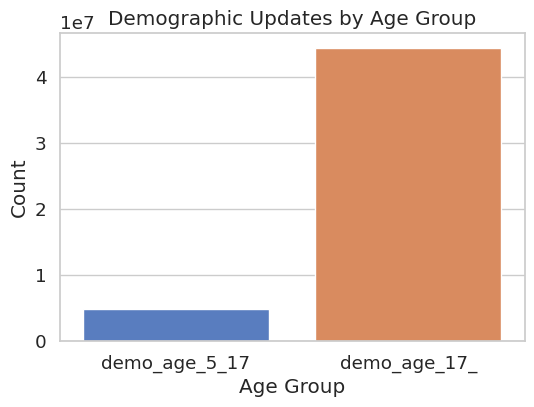

In [ ]:
age_summary = demo_df[['demo_age_5_17','demo_age_17_']].sum().reset_index()
age_summary.columns = ['Age Group','Count']

plt.figure(figsize=(6,4))
sns.barplot(data=age_summary, x='Age Group', y='Count', palette="muted")
plt.title("Demographic Updates by Age Group")
plt.show()

<Figure size 1000x600 with 0 Axes>

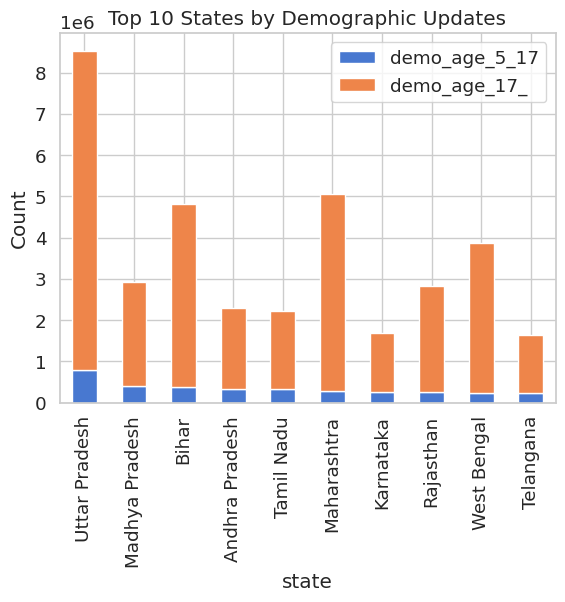

In [ ]:
state_summary = demo_df.groupby('state')[['demo_age_5_17','demo_age_17_']].sum().reset_index()

top_states = state_summary.sort_values(by=['demo_age_5_17','demo_age_17_'], ascending=False).head(10)

plt.figure(figsize=(10,6))
top_states.set_index('state')[['demo_age_5_17','demo_age_17_']].plot(kind='bar', stacked=True)
plt.title("Top 10 States by Demographic Updates")
plt.ylabel("Count")
plt.show()

In [ ]:
district_summary = demo_df.groupby(['state','district'])[['demo_age_5_17','demo_age_17_']].sum().reset_index()

heatmap = alt.Chart(district_summary).mark_rect().encode(
    x='district:N',
    y='state:N',
    color='demo_age_5_17:Q',
    tooltip=['state','district','demo_age_5_17','demo_age_17_']
).properties(
    width=800,
    height=600,
    title="Trivariate: Heatmap of Demographic Updates (5–17 age group)"
)

heatmap.show()

alt.Chart(...)

Number of anomalous districts: 1426666
Top anomalies:
            state           district  pincode  demo_age_5_17  demo_age_17_  \
0   Uttar Pradesh          Gorakhpur   273213             49           529   
1  Andhra Pradesh           Chittoor   517132             22           375   
2         Gujarat             Rajkot   360006             65           765   
3  Andhra Pradesh         Srikakulam   532484             24           314   
4       Rajasthan            Udaipur   313801             45           785   
5       Rajasthan              Sikar   332028             28           285   
6       Karnataka           Tumakuru   572201             88           332   
7   Uttar Pradesh          Gorakhpur   273211             61           836   
8  Andhra Pradesh            Kurnool   518313             83           986   
9     West Bengal  Paschim Medinipur   721148             13           281   

   ratio_17plus  
0     10.795918  
1     17.045455  
2     11.769231  
3     13.083333

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


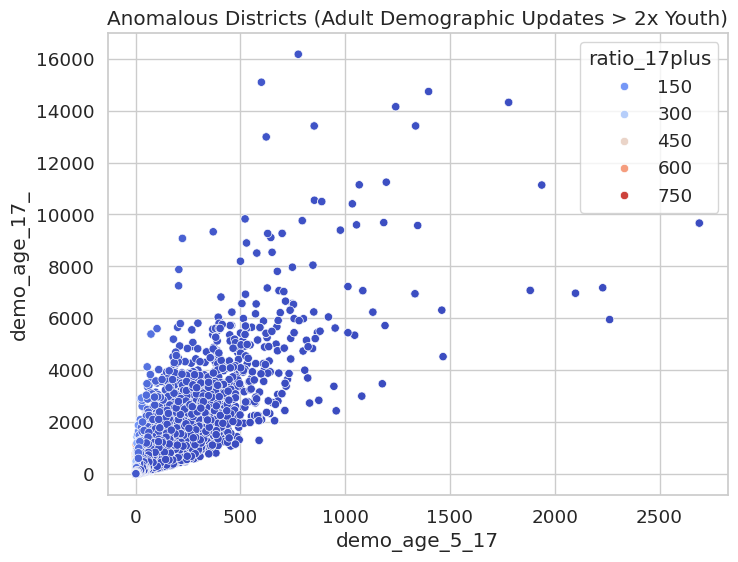

In [ ]:
# Ratio of adult to youth demographic updates
demo_df['ratio_17plus'] = demo_df['demo_age_17_'] / (demo_df['demo_age_5_17'].replace(0, 1))

anomalies = demo_df[demo_df['ratio_17plus'] > 2]

print("Number of anomalous districts:", len(anomalies))
print("Top anomalies:")
print(anomalies[['state','district','pincode','demo_age_5_17','demo_age_17_','ratio_17plus']].head(10))

plt.figure(figsize=(8,6))
sns.scatterplot(data=anomalies, x='demo_age_5_17', y='demo_age_17_', hue='ratio_17plus', palette="coolwarm")
plt.title("Anomalous Districts (Adult Demographic Updates > 2x Youth)")
plt.show()

In [ ]:
total_youth = demo_df['demo_age_5_17'].sum()
total_adult = demo_df['demo_age_17_'].sum()

top_youth_state = demo_df.groupby('state')['demo_age_5_17'].sum().idxmax()
top_youth_value = demo_df.groupby('state')['demo_age_5_17'].sum().max()

top_adult_state = demo_df.groupby('state')['demo_age_17_'].sum().idxmax()
top_adult_value = demo_df.groupby('state')['demo_age_17_'].sum().max()

print(" Key Insights (Demographics):")
print(f"- Youth (5–17) demographic updates total {total_youth}, compared to {total_adult} adult updates.")
print(f"- {top_youth_state} leads in youth updates ({top_youth_value}).")
print(f"- {top_adult_state} leads in adult updates ({top_adult_value}).")
print(f"- {len(anomalies)} districts show adult updates more than double youth updates.")
print("- These anomalies may indicate targeted adult demographic campaigns or operational imbalances.")

 Key Insights (Demographics):
- Youth (5–17) demographic updates total 4863424, compared to 44431763 adult updates.
- Uttar Pradesh leads in youth updates (790308).
- Uttar Pradesh leads in adult updates (7752020).
- 1426666 districts show adult updates more than double youth updates.
- These anomalies may indicate targeted adult demographic campaigns or operational imbalances.


In [ ]:
from google.colab import files

demo_df.to_csv("demographic_master.csv", index=False)
files.download("demographic_master.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>